# Исследование надежности заемщиков


Во второй части проекта вы выполните шаги 3 и 4. Их вручную проверит ревьюер.
Чтобы вам не пришлось писать код заново для шагов 1 и 2, мы добавили авторские решения в ячейки с кодом. 



## Откройте таблицу и изучите общую информацию о данных

**Задание 1. Импортируйте библиотеку pandas. Считайте данные из csv-файла в датафрейм и сохраните в переменную `data`. Путь к файлу:**

`/datasets/data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    data = pd.read_csv('/datasets/data.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/data.csv')

**Задание 2. Выведите первые 20 строчек датафрейма `data` на экран.**

In [2]:
data.head(20)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу
5,0,-926.185831,27,высшее,0,гражданский брак,1,M,компаньон,0,255763.565419,покупка жилья
6,0,-2879.202052,43,высшее,0,женат / замужем,0,F,компаньон,0,240525.971920,операции с жильем
7,0,-152.779569,50,СРЕДНЕЕ,1,женат / замужем,0,M,сотрудник,0,135823.934197,образование
8,2,-6929.865299,35,ВЫСШЕЕ,0,гражданский брак,1,F,сотрудник,0,95856.832424,на проведение свадьбы
9,0,-2188.756445,41,среднее,1,женат / замужем,0,M,сотрудник,0,144425.938277,покупка жилья для семьи


**Задание 3. Выведите основную информацию о датафрейме с помощью метода `info()`.**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


## Предобработка данных

### Удаление пропусков

**Задание 4. Выведите количество пропущенных значений для каждого столбца. Используйте комбинацию двух методов.**

In [4]:
data.isna().sum()

children               0
days_employed       2174
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income        2174
purpose                0
dtype: int64

**Задание 5. В двух столбцах есть пропущенные значения. Один из них — `days_employed`. Пропуски в этом столбце вы обработаете на следующем этапе. Другой столбец с пропущенными значениями — `total_income` — хранит данные о доходах. На сумму дохода сильнее всего влияет тип занятости, поэтому заполнить пропуски в этом столбце нужно медианным значением по каждому типу из столбца `income_type`. Например, у человека с типом занятости `сотрудник` пропуск в столбце `total_income` должен быть заполнен медианным доходом среди всех записей с тем же типом.**

In [5]:
for t in data['income_type'].unique():
    data.loc[(data['income_type'] == t) & (data['total_income'].isna()), 'total_income'] = \
    data.loc[(data['income_type'] == t), 'total_income'].median()

### Обработка аномальных значений

**Задание 6. В данных могут встречаться артефакты (аномалии) — значения, которые не отражают действительность и появились по какой-то ошибке. таким артефактом будет отрицательное количество дней трудового стажа в столбце `days_employed`. Для реальных данных это нормально. Обработайте значения в этом столбце: замените все отрицательные значения положительными с помощью метода `abs()`.**

In [6]:
data['days_employed'] = data['days_employed'].abs()

**Задание 7. Для каждого типа занятости выведите медианное значение трудового стажа `days_employed` в днях.**

In [7]:
data.groupby('income_type')['days_employed'].agg('median')

income_type
безработный        366413.652744
в декрете            3296.759962
госслужащий          2689.368353
компаньон            1547.382223
пенсионер          365213.306266
предприниматель       520.848083
сотрудник            1574.202821
студент               578.751554
Name: days_employed, dtype: float64

У двух типов (безработные и пенсионеры) получатся аномально большие значения. Исправить такие значения сложно, поэтому оставьте их как есть. Тем более этот столбец не понадобится вам для исследования.

**Задание 8. Выведите перечень уникальных значений столбца `children`.**

In [8]:
data['children'].unique()

array([ 1,  0,  3,  2, -1,  4, 20,  5], dtype=int64)

**Задание 9. В столбце `children` есть два аномальных значения. Удалите строки, в которых встречаются такие аномальные значения из датафрейма `data`.**

In [9]:
data = data[(data['children'] != -1) & (data['children'] != 20)]

**Задание 10. Ещё раз выведите перечень уникальных значений столбца `children`, чтобы убедиться, что артефакты удалены.**

In [10]:
data['children'].unique()

array([1, 0, 3, 2, 4, 5], dtype=int64)

### Удаление пропусков (продолжение)

**Задание 11. Заполните пропуски в столбце `days_employed` медианными значениями по каждого типа занятости `income_type`.**

In [11]:
for t in data['income_type'].unique():
    data.loc[(data['income_type'] == t) & (data['days_employed'].isna()), 'days_employed'] = \
    data.loc[(data['income_type'] == t), 'days_employed'].median()

**Задание 12. Убедитесь, что все пропуски заполнены. Проверьте себя и ещё раз выведите количество пропущенных значений для каждого столбца с помощью двух методов.**

In [12]:
data.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

### Изменение типов данных

**Задание 13. Замените вещественный тип данных в столбце `total_income` на целочисленный с помощью метода `astype()`.**

In [13]:
data['total_income'] = data['total_income'].astype(int)

### Обработка дубликатов

**Задание 14. Обработайте неявные дубликаты в столбце `education`. В этом столбце есть одни и те же значения, но записанные по-разному: с использованием заглавных и строчных букв. Приведите их к нижнему регистру. Проверьте остальные столбцы.**

In [14]:
data['education'] = data['education'].str.lower()

**Задание 15. Выведите на экран количество строк-дубликатов в данных. Если такие строки присутствуют, удалите их.**

In [15]:
data.duplicated().sum()

71

In [16]:
data = data.drop_duplicates()

### Категоризация данных

**Задание 16. На основании диапазонов, указанных ниже, создайте в датафрейме `data` столбец `total_income_category` с категориями:**

- 0–30000 — `'E'`;
- 30001–50000 — `'D'`;
- 50001–200000 — `'C'`;
- 200001–1000000 — `'B'`;
- 1000001 и выше — `'A'`.


**Например, кредитополучателю с доходом 25000 нужно назначить категорию `'E'`, а клиенту, получающему 235000, — `'B'`. Используйте собственную функцию с именем `categorize_income()` и метод `apply()`.**

In [17]:
def categorize_income(income):
    try:
        if 0 <= income <= 30000:
            return 'E'
        elif 30001 <= income <= 50000:
            return 'D'
        elif 50001 <= income <= 200000:
            return 'C'
        elif 200001 <= income <= 1000000:
            return 'B'
        elif income >= 1000001:
            return 'A'
    except:
        pass

In [18]:
data['total_income_category'] = data['total_income'].apply(categorize_income)

**Задание 17. Выведите на экран перечень уникальных целей взятия кредита из столбца `purpose`.**

In [19]:
data['purpose'].unique()

array(['покупка жилья', 'приобретение автомобиля',
       'дополнительное образование', 'сыграть свадьбу',
       'операции с жильем', 'образование', 'на проведение свадьбы',
       'покупка жилья для семьи', 'покупка недвижимости',
       'покупка коммерческой недвижимости', 'покупка жилой недвижимости',
       'строительство собственной недвижимости', 'недвижимость',
       'строительство недвижимости', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля',
       'операции с коммерческой недвижимостью',
       'строительство жилой недвижимости', 'жилье',
       'операции со своей недвижимостью', 'автомобили',
       'заняться образованием', 'сделка с подержанным автомобилем',
       'получение образования', 'автомобиль', 'свадьба',
       'получение дополнительного образования', 'покупка своего жилья',
       'операции с недвижимостью', 'получение высшего образования',
       'свой автомобиль', 'сделка с автомобилем',
       'профильное образование', 'высшее об

**Задание 18. Создайте функцию, которая на основании данных из столбца `purpose` сформирует новый столбец `purpose_category`, в который войдут следующие категории:**

- `'операции с автомобилем'`,
- `'операции с недвижимостью'`,
- `'проведение свадьбы'`,
- `'получение образования'`.

**Например, если в столбце `purpose` находится подстрока `'на покупку автомобиля'`, то в столбце `purpose_category` должна появиться строка `'операции с автомобилем'`.**

**Используйте собственную функцию с именем `categorize_purpose()` и метод `apply()`. Изучите данные в столбце `purpose` и определите, какие подстроки помогут вам правильно определить категорию.**

In [20]:
def categorize_purpose(row):
    try:
        if 'автом' in row:
            return 'операции с автомобилем'
        elif 'жил' in row or 'недвиж' in row:
            return 'операции с недвижимостью'
        elif 'свад' in row:
            return 'проведение свадьбы'
        elif 'образов' in row:
            return 'получение образования'
    except:
        return 'нет категории'

In [21]:
data['purpose_category'] = data['purpose'].apply(categorize_purpose)

### Шаг 3. Исследуйте данные и ответьте на вопросы

#### 3.1 Есть ли зависимость между количеством детей и возвратом кредита в срок?

Количество детей в семье, которые взяли кредит:
children
0    14091
1     4808
2     2052
3      330
4       41
5        9
Name: debt, dtype: int64
Процент задолженности кредита в зависимости от количества детей в семье:
children
0    7.543822
1    9.234609
2    9.454191
3    8.181818
4    9.756098
5    0.000000
Name: debt, dtype: float64

Прямоугольная диаграмма укажет на выбросы в данных


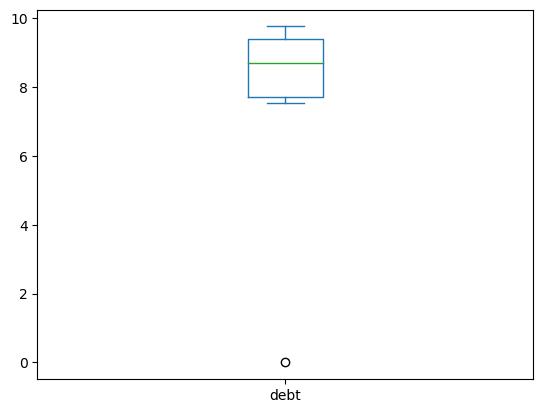

Корреляция Пирсона (PCC) = -0.5404158233817098 для всех семей
Корреляция Пирсона (PCC) = 0.5711330411621426 для семей с количеством детей до 4 включительно


In [22]:
# сгрупперуем по количеству детей ('children') и посчитаем количество задолженности в каждой группе('debt')
children_sum = data.groupby('children')['debt'].sum()
#print (children_sum)
# расчитаем общее количество семей в каждой группе
children_count = data.groupby('children')['debt'].count()
print ('Количество детей в семье, которые взяли кредит:')
print (children_count)
# определим процент задолженности кредита к количеству кредитов в каждой группе
percent_debt = children_sum / children_count * 100
print ('Процент задолженности кредита в зависимости от количества детей в семье:')
print (percent_debt)

# визуальным методом "Прямоугольная диаграмма" выявим выбросы в данных:
# процент задолженности кредита к количеству кредитов в каждой группе
# вызовем библиотеку 
# вызов библиотеки перенесен в начало кода import matplotlib.pyplot as plt
# Построим диаграмму
print ('')
print ('Прямоугольная диаграмма укажет на выбросы в данных')
percent_debt.plot(kind='box')
plt.show()
# Прямоугольная диаграмма явно указывает на выброс со значением 0.0 
# а это значение для семей с количеством детей 5 и 100 % возвратом кредитов
# следовательно:
# Данные не однозначны, возможно, нужна большая выборка, чем та, на которой мы производим анализ.

# Проведем контрольный анализ данных (на всех данных и исключая выброс)
# Подготовим данные для расчета корреляции Пирсона (PCC)
# Сохнаним в переменной number_of_children уникальные значения столбца data['children']
#  отсортируем их по возрастанию и присвоим новые индексы
number_of_children = data['children'].drop_duplicates().sort_values().reset_index(drop=True)
#print (number_of_children)
# проверим на линейную зависимость % задолженности по кредиту от количества детей в семье 
# методом расчета корреляции Пирсона (PCC) для всех семей
print ('Корреляция Пирсона (PCC) =',number_of_children.corr(percent_debt), 'для всех семей')
# Полученное значение PCC = -0.54
# исключим аномальную выборку из расчетов (количество детей в семье 5)
number_of_children = number_of_children.drop(labels = [5],axis = 0)
#print(children_namber)
percent_debt = percent_debt.drop(labels = [5],axis = 0)
#print (percent_debt)
print ('Корреляция Пирсона (PCC) =',number_of_children.corr(percent_debt), 'для семей с количеством детей до 4 включительно')
# Полученное значение PCC = +0.57
# Согласно общим понятиям Сила корреляционной связи Пирсона (PCC) оценивается как: 
# слабая: от 0 до ±0,299 ; средняя: от ±0,3 до ±0,699 ; сильная от ±0,7 до ±1 .

# При исключении аномальной выборки (семьи с количеством детей 5) из расчетов
# корреляция Пирсона (PCC) изменила знак на противоположный, что указывает на то, что
# указанное значение является аномальным выбросом и требуется дополнительное исследование
# которое выражается в наборе дополнительных статистических данных (хотя бы по семьям с 5 детьми)

# полученное значение корреляции Пирсона PCC = +0,57 со средней зависимостью для представленной
# выборки, с учетом исключения аномального выброса (семьи с количеством детей 5), указывает на то что, 
# с увеличением количества детей в семье увеличивается % невозвра кредита в установленные сроки

# возможно в выборку попали только добросовестные заёмщики с количеством детей в семье 5
# так как их количество в общей выборке мало (9 семей или 9/21525*100=0,04 %) 

# Проведя дополнительный анализ мы подтвердили свой первоначальный вывод:
# Данные не однозначны, возможно, нужна большая выборка, чем та, на которой мы производим анализ.


**Вывод:**

При анализе данных обнаружен выброс в данных:
+ У семей с количеством детей 5 нет задолженности по возврату кредитов 

При этом таких семей всего 9 в представленной выборке из 21525 строк, 
что составляет 0,0418 % и указывает на недостаточность данных, для оценки семей с количеством детей 5

В то же самое время полученное значение корреляции Пирсона PCC = +0,57 со средней зависимостью для представленной
выборки, с учетом исключения аномального выброса (семьи с количеством детей 5), указывает на то что, 
с увеличением количества детей в семье увеличивается % невозвра кредита в установленные сроки

общее заключение:

**Данные не однозначны, возможно, нужна большая выборка, чем та, на которой мы производим анализ.**

In [23]:
# Определим функцию вычисляющюю процент невозврата кредита в срок с точностью 2 знака после запятой
def my_mean(x):
    return '{:.2%} '.format(x.mean())
# сгруппируем по количеству детей и агрегированием вычислим количество семей и процент невозврата кредита в срок в каждой группе
data.groupby('children')['debt'].agg(['count', my_mean])

,count,my_mean
children,,
0,14091,7.54%
1,4808,9.23%
2,2052,9.45%
3,330,8.18%
4,41,9.76%
5,9,0.00%


**Вывод:**
    
На вопрос:   
Есть ли зависимость между количеством детей и возвратом кредита в срок?

Можно сделать следующий ответ:
    
**Да зависимость есть: увеличение количества детей в семье негативно влияет на возврат кредита в срок, при этом есть особенность:**
1. **Семьи, с количеством детей три, ведут себя более ответственно, чем семьи с одним и двумя детьми.**
    + Возможно существуют меры социальной поддержки.
    

2. **В семьях, с количеством детей пять, наблюдается резкое снижение просроченных кредитов вплоть до нуля.**
    + В этом случае можно сказать, что к рождению пятого ребенка в семье, люди приходят осознано (твердо стоят на ногах и могут себе позволить пятого ребенка без кредитов или существуют меры дополнительной социальной поддержки) или система выдачи кредитов построена таким образом, что кредит семьям имеющим пятого ребенка выдают только в том случае, если они вернут его в обязательном порядке.

#### 3.2 Есть ли зависимость между семейным положением и возвратом кредита в срок?

family_status          family_status_id
вдовец / вдова         2                   6.624606
в разводе              3                   7.064760
женат / замужем        0                   7.560558
гражданский брак       1                   9.313014
Не женат / не замужем  4                   9.763948
Name: debt, dtype: float64

Прямоугольная диаграмма укажет на выбросы в данных


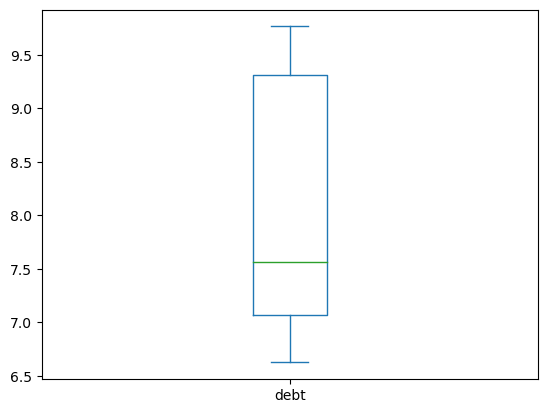

Корреляция Пирсона (PCC) = 0.9671212430033013 


In [24]:
# проведем группировку по столбцам 'family_status','family_status_id' найтем сумму и количество
# в каждой подгруппе
family_count = data.groupby(['family_status','family_status_id'])['debt'].count()
#print (family_count)
family_sum = data.groupby(['family_status','family_status_id'])['debt'].sum()
#print (family_sum)
# определим процент задолженности в каждой группе и проведем сортировку по найденному столбцу:
# процент задолженности в порядке возрастания выведем на печать
print ((family_sum / family_count * 100).sort_values())
# По представленным данным можно увидеть, что существует возрастающая связь между
# семейным положением и процентом задолженности, но значения семейного статуса family_status_id 
# распределены не по возрастающей, а следовательно зависимость наблюдается между
# столбцом family_status и процентом задолженности.

# Проведем анализ этой связи
# в переменной percent_debt_family сохраним вычесленные проценты и присвоим новые индексы
percent_debt_family = (family_sum / family_count * 100).sort_values().reset_index(drop=True)
#print (percent_debt_family)

# визуальным методом "Прямоугольная диаграмма" выявим выбросы
# в данных: процент задолженности кредита к количеству кредитов в каждой группе
# вызовем библиотеку 
# вызов библиотеки перенесен в начало кода import matplotlib.pyplot as plt
# Построим диаграмму 
print ('')
print ('Прямоугольная диаграмма укажет на выбросы в данных')
percent_debt_family.plot(kind='box')
plt.show()
# Прямоугольная диаграмма явно указывает на отсутствие выбросов в проведенных расчетах 
# значит можно проводить проверку на представленной выборке

# В переменной namber сохраним все уникальные значения 'family_status_id' отсортируем 
# по возрастанию и присвоим новые индексы
namber = data['family_status_id'].drop_duplicates().sort_values().reset_index(drop=True)
#print (namber)

# Вычислим Корреляцию Пирсона (PCC) между столбцами данными в namber и percent_debt_family
print ('Корреляция Пирсона (PCC) =', namber.corr(percent_debt_family), '')
# Полученное значение Корреляция Пирсона (PCC) = +0.967
# Согласно общим понятиям Сила корреляционной связи Пирсона (PCC) оценивается как: 
# слабая: от 0 до ±0,299 ; средняя: от ±0,3 до ±0,699 ; сильная от ±0,7 до ±1 .

# полученное значение корреляции Пирсона PCC = +0,967 указывает на сильную линейную связь
# в выборке, между увеличением % невозврата кредита в установленные сроки и семейным положением
# в следующем порядке:
# family_status          family_status_id
# вдовец / вдова         2                   6.624606
# в разводе              3                   7.064760
# женат / замужем        0                   7.560558
# гражданский брак       1                   9.313014
# Не женат / не замужем  4                   9.763948

**Вывод:**

**Между семейным положением и возвратом кредита в срок существует сильная линейная связь.**

При расположений семейного положения в следующем порядке увеличивается и % невозврата кредита в установленный срок

\ |family_status          |family_status_id    | % невозврата кредита в срок
--|-----------------------|--------------------|-----------
1 |вдовец / вдова         |2                   |6.624606
2 |в разводе              |3                   |7.064760
3 |женат / замужем        |0                   |7.560558
4 |гражданский брак       |1                   |9.313014
5 |Не женат / не замужем  |4                   |9.763948

In [25]:
# сгруппируем по категориям и агрегированием вычислим процент невозврата кредита в срок в каждой группе, отсортируеи по family_status_id
data.groupby(['family_status','family_status_id'])['debt'].agg(['count', my_mean]).sort_values('family_status_id')

,,count,my_mean
family_status,family_status_id,,
женат / замужем,0,12261,7.56%
гражданский брак,1,4134,9.31%
вдовец / вдова,2,951,6.62%
в разводе,3,1189,7.06%
Не женат / не замужем,4,2796,9.76%


**Вывод:**
    
На вопрос:   
Есть ли зависимость между семейным положением и возвратом кредита в срок?

Можно сделать следующий ответ:
    
**Да зависимость есть: семейное положение влияет на возврат кредита в срок, при этом есть особенность:**
1. **Заёмщики, со статусом: "Не женат / не замужем", имеют задолженность по возврату кредитов 9,76 % (больше всех).**
    + Возможно это молодые люди без опыта, которым пока нечего терять.
    

2. **Заёмщики, со статусом: "вдовец / вдова", имеют задолженность по возврату кредитов 6,62 % (меньше всех).**
    + Скорее всего тут сказывается пройденный жизненный опыт. Вдовцовы - это люди, прошедшие почти через все категории семейных взаимоотношений.

#### 3.3 Есть ли зависимость между уровнем дохода и возвратом кредита в срок?

In [26]:
# На основании диапазонов и созданного столбеца total_income_category с категориями:

#    0–30000 — 'E';
#    30001–50000 — 'D';
#    50001–200000 — 'C';
#    200001–1000000 — 'B';
#    1000001 и выше — 'A'.

# проведем группировку по столбцу total_income_category найтем сумму и количество
# в каждой подгруппе
total_incomey_sum = data.groupby(['total_income_category'])['debt'].sum()
#print (total_incomey_sum)
total_income_count = data.groupby(['total_income_category'])['debt'].count()
#print (total_income_count)
# определим процент задолженности в каждой группе:
# процент задолженности по диапазонам выведем на печать
print ((total_incomey_sum / total_income_count *100 ))
# В представленных данных в соответствии с разбиением на диапазоны по заработной плате
# Не прослеживается явная зависимость между уровнем дохода и возвратом кредита в срок

# отсортируем по проценту задолженности
print ((total_incomey_sum / total_income_count *100 ).sort_values())
# В тоже самое время больше всего невозвратов кредита в срок у людей с минимальным доходом
# а лучше всех возвращают кредит люди с достатком ниже среднего

total_income_category
A    8.000000
B    7.060231
C    8.498210
D    6.017192
E    9.090909
Name: debt, dtype: float64
total_income_category
D    6.017192
B    7.060231
A    8.000000
C    8.498210
E    9.090909
Name: debt, dtype: float64


In [27]:
# сгруппируем по категориb и агрегированием вычислим процент невозврата кредита в срок в каждой группе, отсортируеи по my_mean
data.groupby(['total_income_category'])['debt'].agg(['count', my_mean]).sort_values('my_mean')

,count,my_mean
total_income_category,,
D,349,6.02%
B,5014,7.06%
A,25,8.00%
C,15921,8.50%
E,22,9.09%


**Вывод:**

В представленных данных в соответствии с разбиением на диапазоны по заработной плате
+    0–30000 — 'E';
+    30001–50000 — 'D';
+    50001–200000 — 'C';
+    200001–1000000 — 'B';
+    1000001 и выше — 'A'.

**Не прослеживается явная зависимость между уровнем дохода и возвратом кредита в срок**

В тоже самое время больше всего невозвратов кредита в срок у людей с минимальным доходом, а лучше всех возвращают кредит люди с достатком ниже среднего.

#### 3.4 Как разные цели кредита влияют на его возврат в срок?

purpose_category
операции с недвижимостью    7.255139
проведение свадьбы          7.911803
получение образования       9.252758
операции с автомобилем      9.347978
Name: debt, dtype: float64

Прямоугольная диаграмма укажет на выбросы в данных


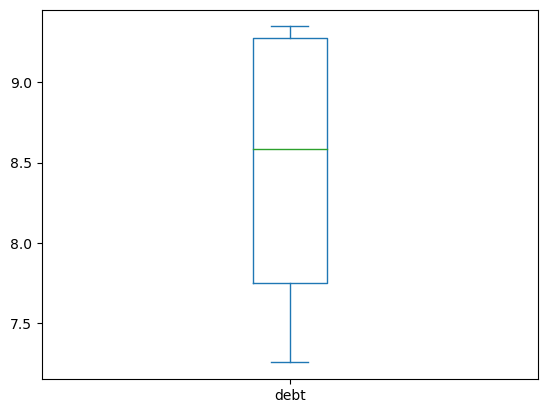

Корреляция Пирсона (PCC) = 0.957251456581113 


In [28]:
# На основании созданного столбеца purpose_category
# проведем группировку по столбцу, найтем сумму и количество
# в каждой подгруппе
purpose_category_sum = data.groupby(['purpose_category'])['debt'].sum()
#print (purpose_category_sum)
purpose_category_count = data.groupby(['purpose_category'])['debt'].count()
#print (purpose_category_count)
# определим процент задолженности в каждой группе и отсортируем по возрастанию:
# процент задолженности по группам выведем на печать
percent_debt_purpose_category = (purpose_category_sum / purpose_category_count *100 ).sort_values()
print (percent_debt_purpose_category)

# визуальным методом "Прямоугольная диаграмма" выявим выбросы в данных:
# процент задолженности кредита к количеству кредитов в каждой группе
# вызовем библиотеку 
# вызов библиотеки перенесен в начало кода import matplotlib.pyplot as plt
# Построим диаграмму 
print ('')
print ('Прямоугольная диаграмма укажет на выбросы в данных')
percent_debt_purpose_category.plot(kind='box')
plt.show()
# Прямоугольная диаграмма явно указывает на отсутствие выбросов в проведенных расчетах 
# значит можно проводить проверку на представленной выборке

# Вычислим Корреляцию Пирсона (PCC) между percent_debt_purpose_category 
# и возрастающими коэффицентами которые зададим как pandas.Series([0, 1, 2, 3])
# так как количество целей кредита мало
# в percent_debt_purpose_category сбросим индексы и присвоим новые
percent_debt_purpose_category = percent_debt_purpose_category.reset_index(drop=True)
# Вычислим Корреляцию
print ('Корреляция Пирсона (PCC) =', pd.Series([0, 1, 2, 3]).corr(percent_debt_purpose_category), '')
# Полученное значение Корреляция Пирсона (PCC) = +0.957
# Согласно общим понятиям Сила корреляционной связи Пирсона (PCC) оценивается как: 
# слабая: от 0 до ±0,299 ; средняя: от ±0,3 до ±0,699 ; сильная от ±0,7 до ±1 .

# полученное значение корреляции Пирсона PCC = +0.957 указывает на сильную линейную связь
# в выборке, между увеличением % невозврата кредита в установленные сроки и целями кредита
# расположенных в следующем порядке:
# операции с недвижимостью    7.255139
# проведение свадьбы          7.911803
# получение образования       9.252758
# операции с автомобилем      9.347978

**Вывод:**

**Между целями кредита и его возвратом в срок  существует сильная линейная связь.**

При расположений целей кредита в следующем порядке увеличивается и % невозврата кредита в установленный срок

\ |purpose_category       | % невозврата кредита в срок
--|----------------------------|---------------
1 |операции с недвижимостью    |7.255139
2 |проведение свадьбы          |7.911803
3 |получение образования       |9.252758
4 |операции с автомобилем      |9.347978

In [29]:
# сгруппируем по категории и агрегированием вычислим процент невозврата кредита в срок в каждой группе, отсортируеи по my_mean
data.groupby(['purpose_category'])['debt'].agg(['count', my_mean]).sort_values('my_mean')

,count,my_mean
purpose_category,,
операции с недвижимостью,10751,7.26%
проведение свадьбы,2313,7.91%
получение образования,3988,9.25%
операции с автомобилем,4279,9.35%


**Вывод:**
    
На вопрос:   
Как разные цели кредита влияют на его возврат в срок?

Можно сделать следующий ответ:
    
+ **Клиенты оформившие кредит на операции с недвижимостью, лучше всех возвращают кредит (7,26% невозврата кредита в срок)**
+ **Клиенты оформившие кредит на операции с автомобилем, самые безответственные клиенты (9,35% невозврата кредита в срок)**
+ **Между ними находятся: те кто брал кредит на проведение свадьбы (7,91%) и получение образования (9,25%)**

#### 3.5 Приведите возможные причины появления пропусков в исходных данных.

*Ответ:*

**"Больше технический" чем "Человеческий"**

В связи с тем что. 
При раскрытии информации методом `data.isna().sum()`
получили вывод следующего содержания:
+ children               0
+ days_employed       2174
+ dob_years              0
+ education              0
+ education_id           0
+ family_status          0
+ family_status_id       0
+ gender                 0
+ income_type            0
+ debt                   0
+ total_income        2174
+ purpose                0
+ dtype: int64

При этом количество пропусков совпадает в незаимосвязанных столбцах:
1.  `days_employed`
2.  `total_income`

оба столбца имеют тип float64

Возможными причиныами появления пропусков в исходных данных являются:
1. Устаревшее программное обеспечение в одном из офисов.
2. Программный сбой при загрузке - выгрузке данных.
3. Человеческий фактор.

#### 3.6 Объясните, почему заполнить пропуски медианным значением — лучшее решение для количественных переменных.

*Ответ:* 

**Медиана** — важная метрика для расчета, потому что она дает нам представление о том, где находится «центр» набора данных. Это также дает нам представление о «типичном» значении в данном наборе данных. Она сглаживает выбросы в данных и несемметричность данных. Если данные имеют нормальное распределение и их количество велико, то медиана будет равняться среднему значению.

### Шаг 4: общий вывод.

**Общий вывод**

В ходе исследования надёжности заемщиков были изучены полученные данные, обработаны и заполнены пропуски, удалены дубликаты и клиенты были объединены в группы по разным параметрам. По итогам проделанной работы по поставленным вопросам можно сделать следующие выводы:

**Есть ли зависимость между количеством детей и возвратом кредита в срок?**

*Да зависимость есть: увеличение количества детей в семье негативно влияет на возврат кредита в срок, при этом есть особенность:*
1. *Семьи, с количеством детей три, ведут себя более ответственно, чем семьи с одним и двумя детьми.*
    + *Возможно существуют меры социальной поддержки.*
    

2. *В семьях, с количеством детей пять, наблюдается резкое снижение просроченных кредитов вплоть до нуля.*
    + *В этом случае можно сказать, что к рождению пятого ребенка в семье, люди приходят осознано (твердо стоят на ногах и могут себе позволить пятого ребенка без кредитов или существуют меры дополнительной социальной поддержки) или система выдачи кредитов построена таким образом, что кредит семьям имеющим пятого ребенка выдают только в том случае, если они вернут его в обязательном порядке.*

**Есть ли зависимость между семейным положением и возвратом кредита в срок?**

*Да зависимость есть: семейное положение влияет на возврат кредита в срок, при этом есть особенность:*
1. *Заёмщики, со статусом: "Не женат / не замужем", имеют задолженность по возврату кредитов 9,76 % (больше всех).*
    + *Возможно это молодые люди без опыта, которым пока нечего терять.*
    

2. *Заёмщики, со статусом: "вдовец / вдова", имеют задолженность по возврату кредитов 6,62 % (меньше всех).*
    + *Скорее всего тут сказывается пройденный жизненный опыт. Вдовцовы - это люди, прошедшие почти через все категории семейных взаимоотношений.*

**Есть ли зависимость между уровнем дохода и возвратом кредита в срок?**

*При разбиении на следующие диапазоны указанные ниже, явная зависимость между уровнем дохода и возвратом кредита в срок не прослеживается*

+    0–30000 — 'E';
+    30001–50000 — 'D';
+    50001–200000 — 'C';
+    200001–1000000 — 'B';
+    1000001 и выше — 'A'.

**Как разные цели кредита влияют на его возврат в срок?**

+ *Клиенты оформившие кредит на операции с недвижимостью, лучше всех возвращают кредит (7,26% невозврата кредита в срок)*
+ *Клиенты оформившие кредит на операции с автомобилем, самые безответственные клиенты (9,35% невозврата кредита в срок)*
+ *Между ними находятся: те кто брал кредит на проведение свадьбы (7,91%) и получение образования (9,25%)*